# 🛒 Customer Segmentation using K-Means Clustering

This notebook builds a customer segmentation model using **K-Means Clustering**.

We use synthetic customer data with features like:
- **Age**
- **Annual Income**
- **Spending Score**
- **Purchase Frequency**

The goal is to group customers into meaningful segments for targeted marketing.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Generate Synthetic Customer Data

In [2]:
np.random.seed(42)
n = 300

# Segment 1: Young, low income, high spending (impulse buyers)
seg1 = pd.DataFrame({
    'Age': np.random.randint(18, 30, 80),
    'Annual_Income_k': np.random.randint(20, 45, 80),
    'Spending_Score': np.random.randint(60, 100, 80),
    'Purchase_Frequency': np.random.randint(10, 20, 80)
})

# Segment 2: Middle-aged, high income, high spending (premium customers)
seg2 = pd.DataFrame({
    'Age': np.random.randint(30, 50, 80),
    'Annual_Income_k': np.random.randint(80, 140, 80),
    'Spending_Score': np.random.randint(65, 100, 80),
    'Purchase_Frequency': np.random.randint(15, 25, 80)
})

# Segment 3: Older, high income, low spending (savers)
seg3 = pd.DataFrame({
    'Age': np.random.randint(45, 70, 70),
    'Annual_Income_k': np.random.randint(70, 120, 70),
    'Spending_Score': np.random.randint(10, 40, 70),
    'Purchase_Frequency': np.random.randint(2, 8, 70)
})

# Segment 4: Middle-aged, low income, low spending (budget shoppers)
seg4 = pd.DataFrame({
    'Age': np.random.randint(25, 55, 70),
    'Annual_Income_k': np.random.randint(15, 40, 70),
    'Spending_Score': np.random.randint(10, 45, 70),
    'Purchase_Frequency': np.random.randint(3, 10, 70)
})

df = pd.concat([seg1, seg2, seg3, seg4], ignore_index=True)
df['CustomerID'] = ['C' + str(i+1).zfill(4) for i in range(len(df))]
df = df[['CustomerID', 'Age', 'Annual_Income_k', 'Spending_Score', 'Purchase_Frequency']]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (300, 5)


,CustomerID,Age,Annual_Income_k,Spending_Score,Purchase_Frequency
0,C0204,62,84,30,2
1,C0267,54,23,13,5
2,C0153,33,89,78,17
3,C0010,28,42,72,17
4,C0234,45,15,26,4
5,C0227,60,86,34,4
6,C0197,63,74,36,2
7,C0110,44,127,87,19
8,C0006,24,35,98,16
9,C0176,65,115,20,7


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Summary Statistics ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          300 non-null    object
 1   Age                 300 non-null    int64 
 2   Annual_Income_k     300 non-null    int64 
 3   Spending_Score      300 non-null    int64 
 4   Purchase_Frequency  300 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 11.8+ KB
None

=== Summary Statistics ===


,Age,Annual_Income_k,Spending_Score,Purchase_Frequency
count,300.00,300.00,300.00,300.00
mean,39.31,65.45,55.67,11.39
std,13.72,39.79,29.83,6.74
min,18.00,15.00,10.00,2.00
25%,28.00,27.00,27.00,5.00
50%,38.00,57.00,62.50,10.50
75%,49.00,103.00,84.00,17.00
max,69.00,139.00,99.00,24.00


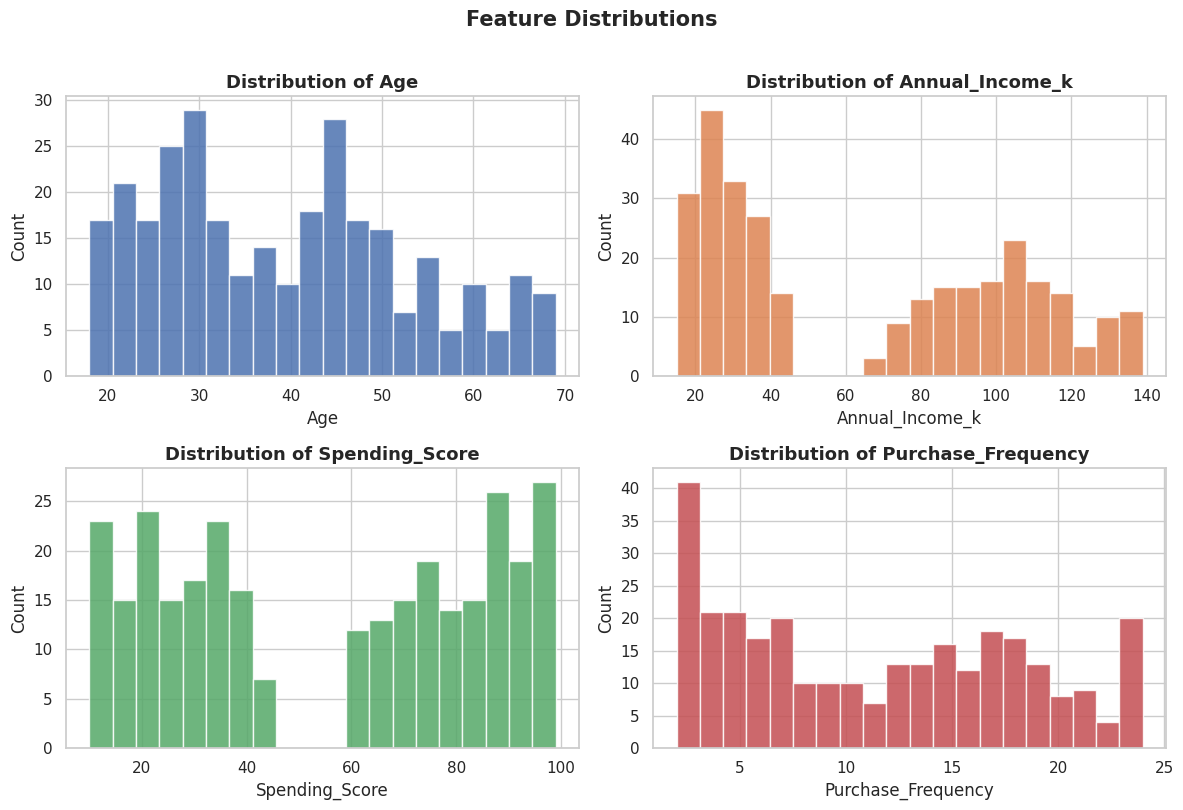

In [4]:
features = ['Age', 'Annual_Income_k', 'Spending_Score', 'Purchase_Frequency']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (col, ax, color) in enumerate(zip(features, axes.flatten(), colors)):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

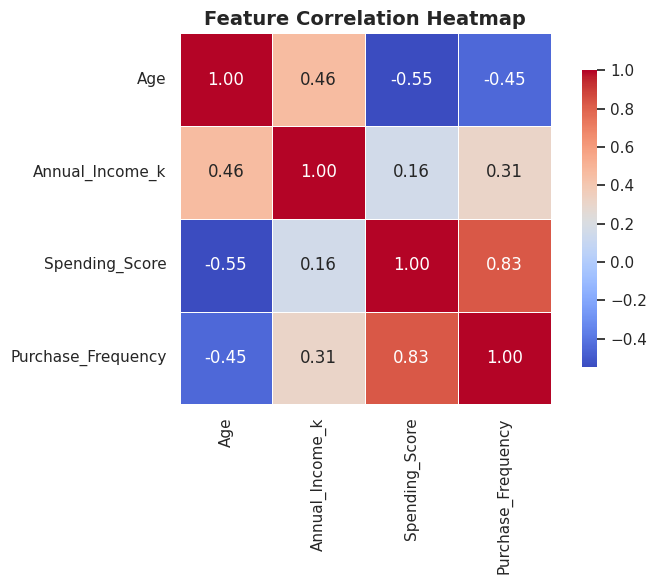

In [5]:
plt.figure(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [6]:
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print('Data scaled successfully!')
print('Mean after scaling:', X_scaled.mean().round(4).to_dict())
print('Std after scaling: ', X_scaled.std().round(4).to_dict())

Data scaled successfully!
Mean after scaling: {'Age': 0.0, 'Annual_Income_k': 0.0, 'Spending_Score': -0.0, 'Purchase_Frequency': 0.0}
Std after scaling:  {'Age': 1.0017, 'Annual_Income_k': 1.0017, 'Spending_Score': 1.0017, 'Purchase_Frequency': 1.0017}


## 5. Find Optimal Number of Clusters
We use two methods:
- **Elbow Method** (Inertia)
- **Silhouette Score**

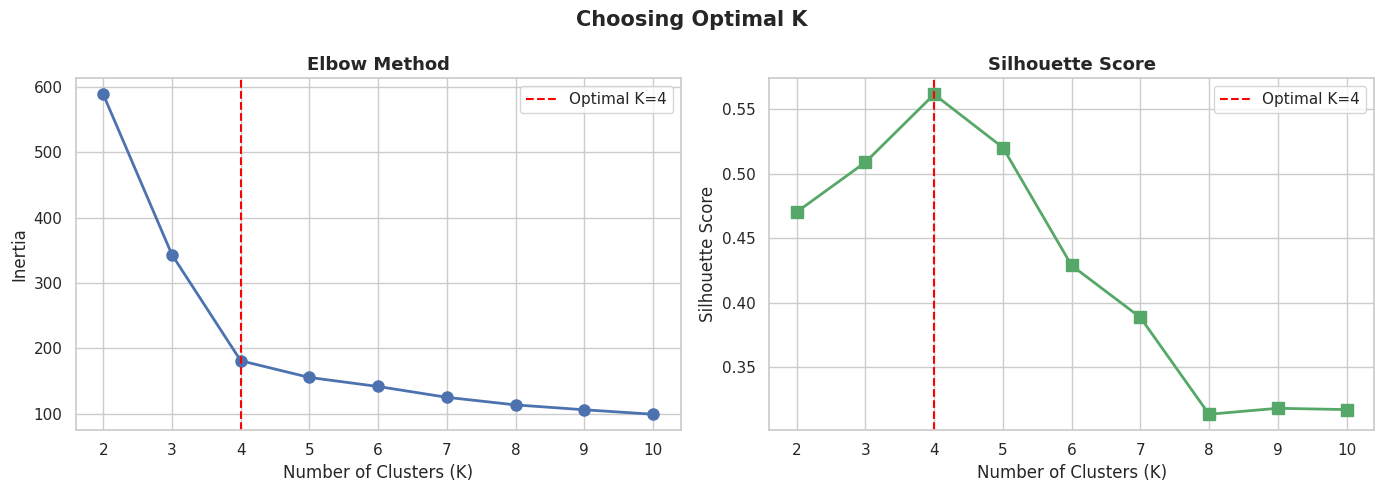

Best Silhouette Score at K=4: 0.5617


In [7]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), silhouettes, 'gs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
axes[1].legend()

plt.suptitle('Choosing Optimal K', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best Silhouette Score at K=4: {silhouettes[2]:.4f}')

## 6. Train K-Means with K=4

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster Distribution:')
print(df['Cluster'].value_counts().sort_index())
print(f'\nFinal Inertia: {kmeans.inertia_:.2f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, df["Cluster"]):.4f}')

Cluster Distribution:
Cluster
0    80
1    70
2    80
3    70
Name: count, dtype: int64

Final Inertia: 181.14
Silhouette Score: 0.5617


## 7. Cluster Profiling

In [9]:
cluster_profile = df.groupby('Cluster')[features].mean().round(1)
cluster_profile['Size'] = df['Cluster'].value_counts().sort_index()

# Assign segment labels
segment_labels = {}
for c in range(4):
    row = cluster_profile.loc[c]
    if row['Spending_Score'] > 55 and row['Annual_Income_k'] > 60:
        segment_labels[c] = '💎 Premium Customers'
    elif row['Spending_Score'] > 55 and row['Annual_Income_k'] <= 60:
        segment_labels[c] = '🛍️ Impulse Buyers'
    elif row['Spending_Score'] <= 55 and row['Annual_Income_k'] > 60:
        segment_labels[c] = '💰 Savers / High Earners'
    else:
        segment_labels[c] = '🏷️ Budget Shoppers'

cluster_profile['Segment'] = pd.Series(segment_labels)
print('=== Cluster Profiles ===')
cluster_profile

=== Cluster Profiles ===


,Age,Annual_Income_k,Spending_Score,Purchase_Frequency,Size,Segment
Cluster,,,,,,
0,39.0,110.6,83.8,19.7,80,💎 Premium Customers
1,57.5,93.5,25.3,4.4,70,💰 Savers / High Earners
2,23.8,30.9,79.6,14.1,80,🛍️ Impulse Buyers
3,39.1,25.3,26.5,5.8,70,🏷️ Budget Shoppers


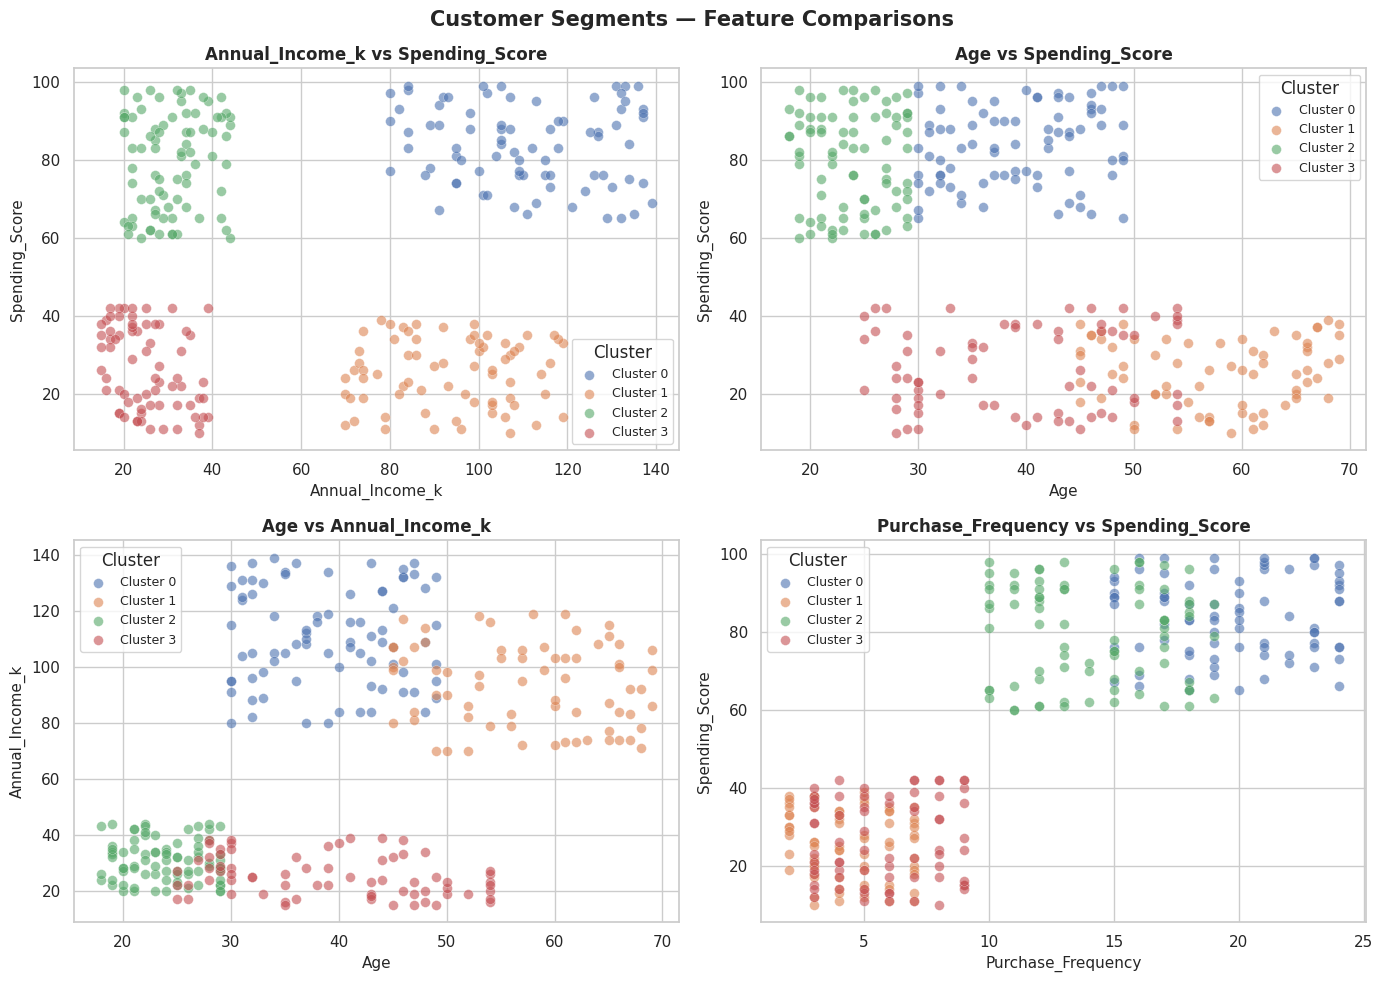

In [10]:
palette = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868', 3: '#C44E52'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [
    ('Annual_Income_k', 'Spending_Score'),
    ('Age', 'Spending_Score'),
    ('Age', 'Annual_Income_k'),
    ('Purchase_Frequency', 'Spending_Score')
]

for ax, (x_col, y_col) in zip(axes.flatten(), pairs):
    for cluster_id in range(4):
        mask = df['Cluster'] == cluster_id
        ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
                   color=palette[cluster_id], label=f'Cluster {cluster_id}',
                   alpha=0.6, s=50, edgecolors='white', linewidth=0.3)
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col, fontsize=11)
    ax.set_title(f'{x_col} vs {y_col}', fontsize=12, fontweight='bold')
    ax.legend(title='Cluster', fontsize=9)

plt.suptitle('Customer Segments — Feature Comparisons', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. PCA Visualization (2D)

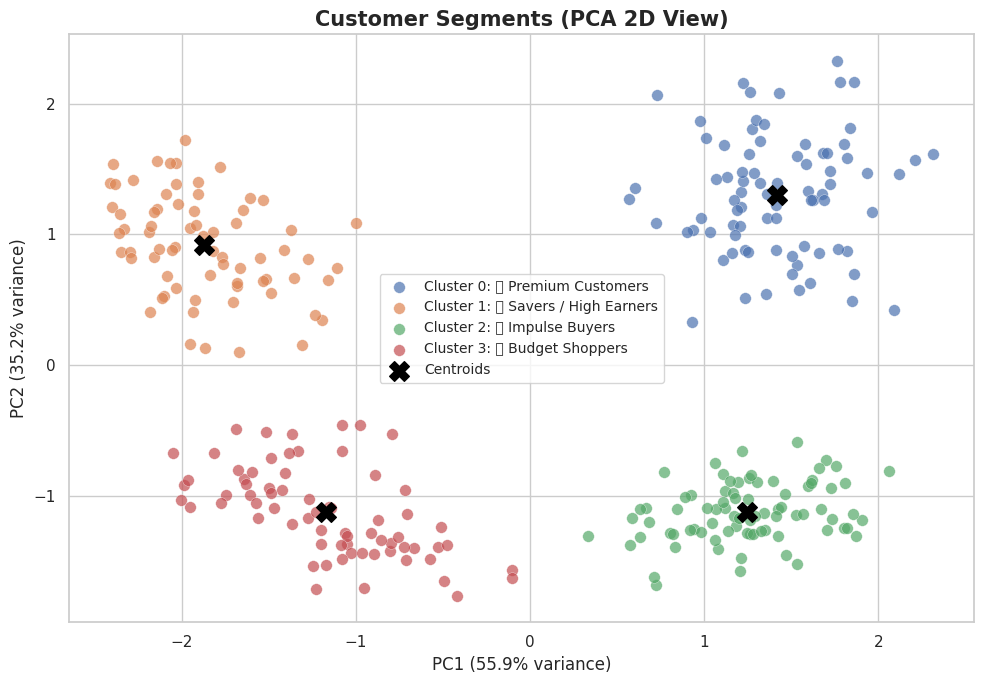

Total variance explained by 2 PCs: 91.1%


In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for cluster_id in range(4):
    mask = df['Cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=palette[cluster_id],
                label=f'Cluster {cluster_id}: {segment_labels[cluster_id]}',
                alpha=0.7, s=70, edgecolors='white', linewidth=0.3)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.title('Customer Segments (PCA 2D View)', fontsize=15, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

print(f'Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

## 9. Segment Radar Chart

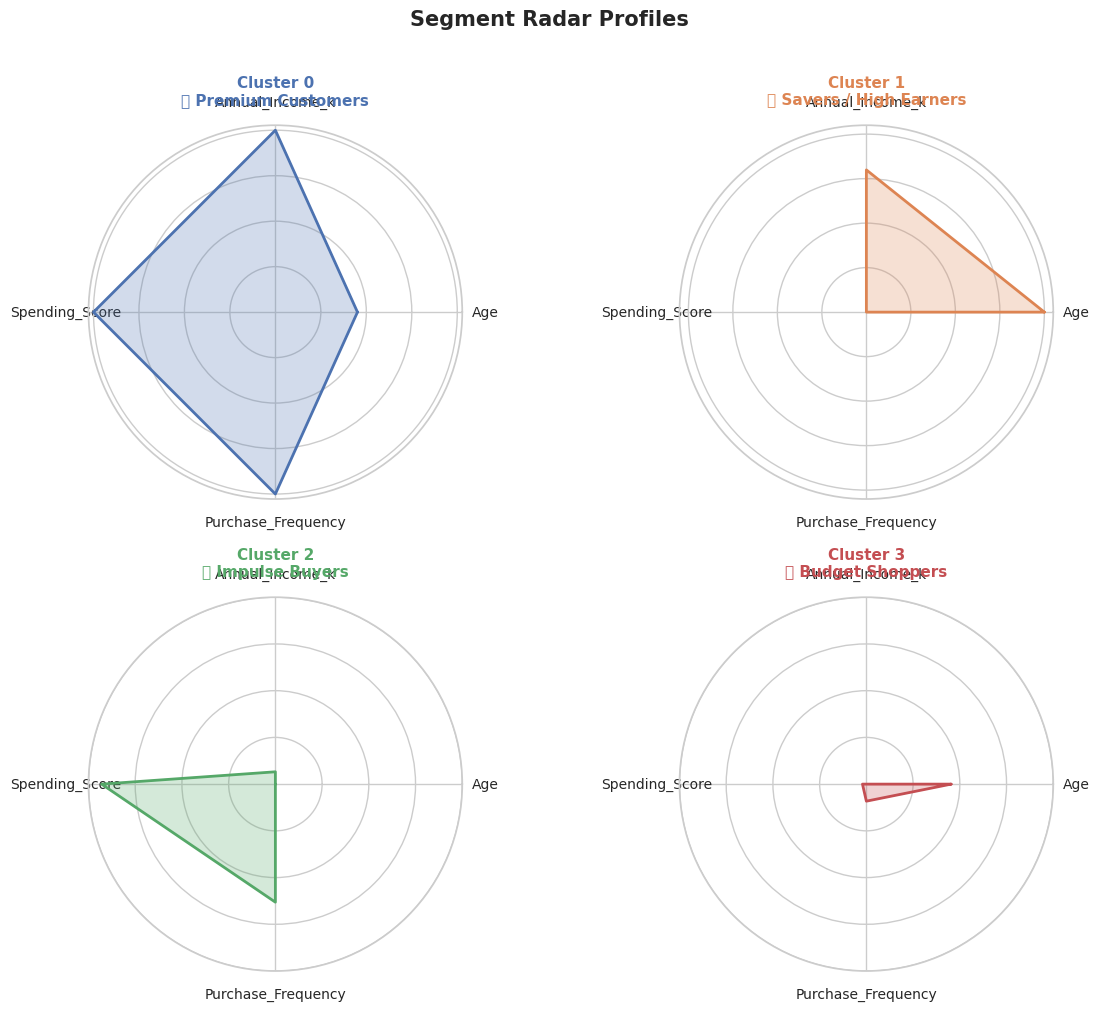

In [12]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalize cluster profiles for radar
radar_data = df.groupby('Cluster')[features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

labels = features
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw=dict(polar=True))
colors_list = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for idx, (ax, cluster_id, color) in enumerate(zip(axes.flatten(), range(4), colors_list)):
    values = radar_norm.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=10)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['', '', '', ''], size=8)
    ax.set_title(f'Cluster {cluster_id}\n{segment_labels[cluster_id]}',
                 size=11, fontweight='bold', pad=15, color=color)

plt.suptitle('Segment Radar Profiles', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Export Results

In [13]:
df['Segment_Label'] = df['Cluster'].map(segment_labels)
df.to_csv('customer_segments.csv', index=False)
print('Results saved to customer_segments.csv')
print('\nFinal Dataset Sample:')
df.head(10)

Results saved to customer_segments.csv

Final Dataset Sample:


,CustomerID,Age,Annual_Income_k,Spending_Score,Purchase_Frequency,Cluster,Segment_Label
0,C0204,62,84,30,2,1,💰 Savers / High Earners
1,C0267,54,23,13,5,3,🏷️ Budget Shoppers
2,C0153,33,89,78,17,0,💎 Premium Customers
3,C0010,28,42,72,17,2,🛍️ Impulse Buyers
4,C0234,45,15,26,4,3,🏷️ Budget Shoppers
5,C0227,60,86,34,4,1,💰 Savers / High Earners
6,C0197,63,74,36,2,1,💰 Savers / High Earners
7,C0110,44,127,87,19,0,💎 Premium Customers
8,C0006,24,35,98,16,2,🛍️ Impulse Buyers
9,C0176,65,115,20,7,1,💰 Savers / High Earners


## 11. Summary & Business Insights

| Segment | Description | Marketing Strategy |
|---|---|---|
| 💎 Premium Customers | High income, high spending | Loyalty programs, exclusive offers |
| 🛍️ Impulse Buyers | Low income, high spending | Flash sales, limited-time deals |
| 💰 Savers / High Earners | High income, low spending | Value propositions, trust-building |
| 🏷️ Budget Shoppers | Low income, low spending | Discounts, bundles, coupons |

---
## 12. 🔮 Predict Segment for a New Customer

Enter the details of a new customer below and run the cell to instantly predict which segment they belong to.

> ✅ **Make sure you have run all cells above first** (the model must be trained before predicting).

In [16]:
new_customer = {
    'Age': 35,                  # Age in years (e.g. 18 - 70)
    'Annual_Income_k': 100,      # Annual income in $000s (e.g. 15 - 140)
    'Spending_Score': 100,       # Spending score 1-100 (higher = spends more)
    'Purchase_Frequency': 20    # Number of purchases per month
}
import pandas as pd

new_df = pd.DataFrame([new_customer])
new_scaled = scaler.transform(new_df)
predicted_cluster = kmeans.predict(new_scaled)[0]
predicted_segment = segment_labels[predicted_cluster]

# Get cluster stats for context
cluster_stats = df.groupby('Cluster')[features].mean().round(1).loc[predicted_cluster]

print('=' * 55)
print('          🔮  CUSTOMER SEGMENT PREDICTION')
print('=' * 55)
print(f'  Age                 : {new_customer["Age"]}')
print(f'  Annual Income       : ${new_customer["Annual_Income_k"]}k')
print(f'  Spending Score      : {new_customer["Spending_Score"]}/100')
print(f'  Purchase Frequency  : {new_customer["Purchase_Frequency"]} / month')
print('-' * 55)
print(f'  Predicted Cluster   : Cluster {predicted_cluster}')
print(f'  Segment             : {predicted_segment}')
print('=' * 55)
print()
print('📊 Average profile of this segment:')
for feat, val in cluster_stats.items():
    print(f'   {feat:<22}: {val}')

# Marketing tip
tips = {
    '💎 Premium Customers'   : '🎯 Strategy: Offer loyalty rewards, VIP programs & exclusive early access.',
    '🛍️ Impulse Buyers'      : '🎯 Strategy: Target with flash sales, limited-time deals & trending products.',
    '💰 Savers / High Earners': '🎯 Strategy: Emphasise value, quality & long-term ROI to earn their trust.',
    '🏷️ Budget Shoppers'     : '🎯 Strategy: Promote discounts, bundles & affordable product lines.'
}
print()
print(tips.get(predicted_segment, ''))

          🔮  CUSTOMER SEGMENT PREDICTION
  Age                 : 35
  Annual Income       : $100k
  Spending Score      : 100/100
  Purchase Frequency  : 20 / month
-------------------------------------------------------
  Predicted Cluster   : Cluster 0
  Segment             : 💎 Premium Customers

📊 Average profile of this segment:
   Age                   : 39.0
   Annual_Income_k       : 110.6
   Spending_Score        : 83.8
   Purchase_Frequency    : 19.7

🎯 Strategy: Offer loyalty rewards, VIP programs & exclusive early access.


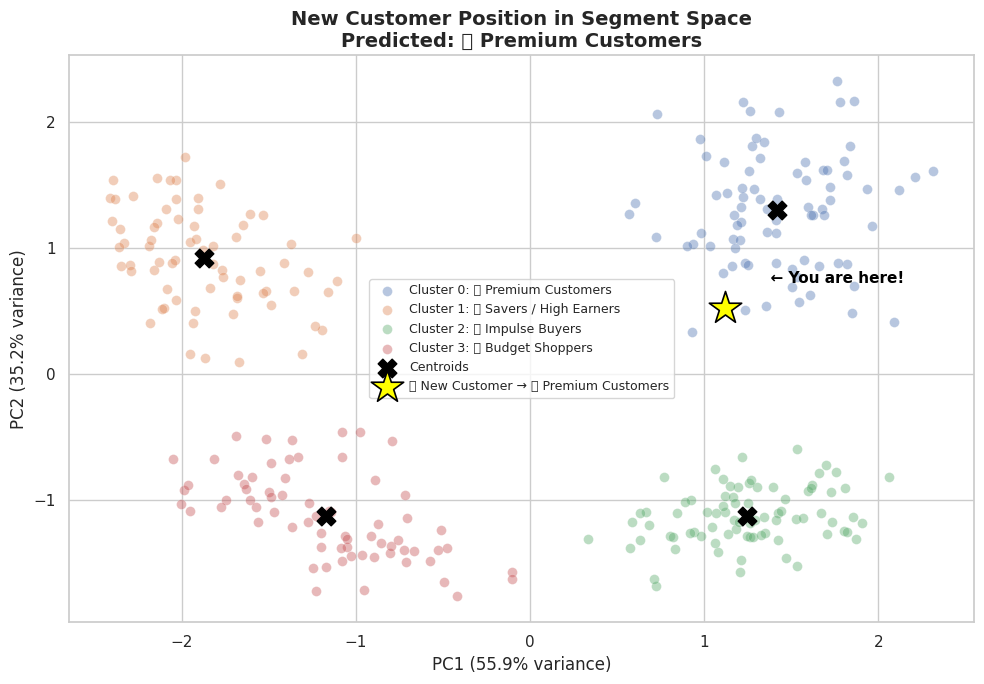

In [15]:
# ============================================================
#  📊  Visualise where the new customer sits among all segments
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pca_new = pca.transform(new_scaled)

plt.figure(figsize=(10, 7))

# Plot existing clusters
for cluster_id in range(4):
    mask = df['Cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=palette[cluster_id],
                label=f'Cluster {cluster_id}: {segment_labels[cluster_id]}',
                alpha=0.4, s=50, edgecolors='white', linewidth=0.3)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=180, zorder=5, label='Centroids')

# Plot new customer with a star
plt.scatter(pca_new[0, 0], pca_new[0, 1],
            c='yellow', marker='*', s=600, zorder=6,
            edgecolors='black', linewidth=1.2,
            label=f'⭐ New Customer → {predicted_segment}')

# Annotate
plt.annotate('  ← You are here!', xy=(pca_new[0, 0], pca_new[0, 1]),
             fontsize=11, fontweight='bold', color='black',
             xytext=(pca_new[0, 0] + 0.2, pca_new[0, 1] + 0.2))

plt.title(f'New Customer Position in Segment Space\nPredicted: {predicted_segment}',
          fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()